In [61]:
import pandas as pd

df = pd.read_csv("../data/data_manifesto_topics.csv")
print(df.columns)
df.head()

Index(['id', 'date', 'titulaire-liste', 'titulaire-profession',
       'titulaire-age-calcule', 'titulaire-sexe', 'departement-insee', 'text',
       'word_count', 'year', 'profession_clean', 'party_clean', 'Topic_0',
       'Topic_1', 'Topic_2', 'Topic_3', 'Topic_4', 'Topic_5', 'Topic_6',
       'Topic_7', 'Topic_8', 'Topic_9'],
      dtype='str')


,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,...,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,...,0.147503,0.000265,0.000265,0.850380,0.000265,0.000265,0.000265,0.000265,0.000265,0.000265
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,...,0.000392,0.000392,0.000392,0.390756,0.000392,0.000392,0.000392,0.000392,0.000392,0.606106
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,...,0.000283,0.000283,0.000283,0.485948,0.000283,0.025883,0.000283,0.000283,0.000283,0.486186
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,...,0.169404,0.000714,0.000714,0.408238,0.000715,0.000714,0.000714,0.193019,0.000714,0.225052
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,...,0.000547,0.000547,0.000547,0.459253,0.000547,0.000547,0.000547,0.000547,0.000547,0.536374


In [62]:
import pandas as pd

df = pd.read_csv("../data/data_manifesto_topics.csv")

topics = [col for col in df.columns if col.startswith("Topic_")]
topics

['Topic_0',
 'Topic_1',
 'Topic_2',
 'Topic_3',
 'Topic_4',
 'Topic_5',
 'Topic_6',
 'Topic_7',
 'Topic_8',
 'Topic_9']

In [63]:
df.shape

(3596, 22)

In [64]:
df["party_clean"].value_counts()

party_clean
Other                                          864
Liste d'entente populaire et nationale         450
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64

In [65]:
df["profession_clean"].value_counts()

profession_clean
Other          1454
Education       617
Health          303
Business        300
Technical       278
Law             195
Worker          188
Agriculture     111
Political        95
Media            55
Name: count, dtype: int64

In [66]:
import statsmodels.formula.api as smf

results = []

for topic in topics:
    
    full_model = smf.ols(
        f"{topic} ~ C(party_clean) + C(profession_clean) + C(year)",
        data=df
    ).fit()

    no_party = smf.ols(
        f"{topic} ~ C(profession_clean) + C(year)",
        data=df
    ).fit()

    no_prof = smf.ols(
        f"{topic} ~ C(party_clean) + C(year)",
        data=df
    ).fit()

    results.append({
        "topic": topic,
        "R2_total": full_model.rsquared,
        "Party_partial_R2": full_model.rsquared - no_party.rsquared,
        "Profession_partial_R2": full_model.rsquared - no_prof.rsquared
    })

variance_df = pd.DataFrame(results)

variance_df

,topic,R2_total,Party_partial_R2,Profession_partial_R2
0,Topic_0,0.820016,0.659811,0.003865
1,Topic_1,0.085729,0.061439,0.005204
2,Topic_2,0.800053,0.483617,0.000362
3,Topic_3,0.613702,0.429202,0.005035
4,Topic_4,0.985118,0.744020,0.000052
5,Topic_5,0.131122,0.094645,0.007812
6,Topic_6,0.038143,0.034646,0.002655
7,Topic_7,0.210030,0.137971,0.006900
8,Topic_8,0.159958,0.111591,0.004979
9,Topic_9,0.346269,0.254520,0.007811


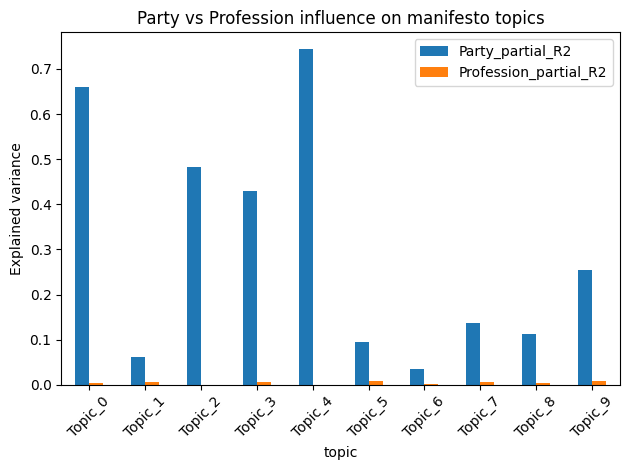

In [67]:
import matplotlib.pyplot as plt

variance_df.set_index("topic")[[
    "Party_partial_R2",
    "Profession_partial_R2"
]].plot(kind="bar")

plt.ylabel("Explained variance")
plt.title("Party vs Profession influence on manifesto topics")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [68]:
variance_df[["Party_partial_R2","Profession_partial_R2"]].mean()

Party_partial_R2         0.301146
Profession_partial_R2    0.004467
dtype: float64

In [69]:
f"{topic} ~ C(party_clean) + C(profession_clean) + year"


'Topic_9 ~ C(party_clean) + C(profession_clean) + year'

In [70]:
import statsmodels.formula.api as smf

results = []

for topic in topics:
    
    full_model = smf.ols(
        f"{topic} ~ C(party_clean) + C(profession_clean) + year",
        data=df
    ).fit()

    no_party = smf.ols(
        f"{topic} ~ C(profession_clean) + year",
        data=df
    ).fit()

    no_prof = smf.ols(
        f"{topic} ~ C(party_clean) + year",
        data=df
    ).fit()

    results.append({
        "topic": topic,
        "R2_total": full_model.rsquared,
        "Party_partial_R2": full_model.rsquared - no_party.rsquared,
        "Profession_partial_R2": full_model.rsquared - no_prof.rsquared
    })

variance_df_numerical = pd.DataFrame(results)

variance_df_numerical

,topic,R2_total,Party_partial_R2,Profession_partial_R2
0,Topic_0,0.819920,0.714540,0.003871
1,Topic_1,0.078163,0.065538,0.004561
2,Topic_2,0.799137,0.608453,0.000371
3,Topic_3,0.608392,0.431664,0.005218
4,Topic_4,0.985106,0.933535,0.000051
5,Topic_5,0.130466,0.102249,0.007901
6,Topic_6,0.012840,0.009742,0.002734
7,Topic_7,0.202894,0.160297,0.007063
8,Topic_8,0.155484,0.117011,0.005088
9,Topic_9,0.345003,0.315567,0.007651


In [71]:
variance_df_numerical[["Party_partial_R2","Profession_partial_R2"]].mean()

Party_partial_R2         0.345859
Profession_partial_R2    0.004451
dtype: float64

In [72]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "Topic_0 ~ C(party_clean) + C(profession_clean)",
    df,
    groups=df["year"]
)

result = model.fit()

print(result.summary())

                                 Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 Topic_0  
No. Observations:                  3596                    Method:                             REML     
No. Groups:                        3                       Scale:                              0.0089   
Min. group size:                   1032                    Log-Likelihood:                     3309.6800
Max. group size:                   1482                    Converged:                          Yes      
Mean group size:                   1198.7                                                               
--------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------

/Users/nysarakpy/github/NLP-Course-Ensae/Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [73]:
mixed_results = []

for topic in topics:

    model = smf.mixedlm(
        f"{topic} ~ C(party_clean) + C(profession_clean)",
        df,
        groups=df["year"]
    )

    result = model.fit()

    mixed_results.append({
        "topic": topic,
        "log_likelihood": result.llf
    })

mixed_df = pd.DataFrame(mixed_results)

mixed_df

/Users/nysarakpy/github/NLP-Course-Ensae/Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/nysarakpy/github/NLP-Course-Ensae/Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/nysarakpy/github/NLP-Course-Ensae/Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/nysarakpy/github/NLP-Course-Ensae/Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimi

,topic,log_likelihood
0,Topic_0,3309.679970
1,Topic_1,2658.834028
2,Topic_2,2470.598818
3,Topic_3,365.261299
4,Topic_4,6429.724104
5,Topic_5,2778.958458
6,Topic_6,5429.380923
7,Topic_7,1843.650549
8,Topic_8,2378.398833
9,Topic_9,405.519335


In [74]:
result.random_effects

{np.int64(1981): Group   -0.103841
 dtype: float64,
 np.int64(1988): Group   -0.019035
 dtype: float64,
 np.int64(1993): Group    0.122876
 dtype: float64}

In [75]:
result.cov_re

,Group
Group,0.013164


In [76]:
import numpy as np

topics = [c for c in df.columns if c.startswith("Topic_")]

topic_matrix = df[topics].values

In [77]:
party_centroids = df.groupby("party_clean")[topics].mean()
party_centroids

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
party_clean,,,,,,,,,,
Alliance des Français pour le progrès,0.031834,0.071563,0.024636,0.239088,0.003689,0.035691,0.002681,0.003038,0.015499,0.572282
Entente des écologistes,0.005601,0.085696,0.752740,0.023474,0.001340,0.009573,0.006614,0.008966,0.015926,0.090068
Liste d'entente populaire et nationale,0.001425,0.003177,0.000650,0.010621,0.970381,0.002057,0.000726,0.000968,0.003377,0.006618
Majorité d'union de la gauche,0.201464,0.011170,0.000676,0.572161,0.000791,0.004724,0.002900,0.096263,0.003626,0.106226
Majorité de la France,0.015292,0.011868,0.003184,0.766499,0.001901,0.020401,0.001593,0.018033,0.027237,0.133993
Majorité présidentielle,0.034322,0.030782,0.010376,0.534109,0.003893,0.024770,0.001071,0.018648,0.025230,0.316800
Majorité présidentielle pour la France unie,0.011821,0.022050,0.003003,0.771872,0.002239,0.023392,0.002838,0.002706,0.021896,0.138184
Other,0.069892,0.079749,0.057937,0.213622,0.005019,0.079395,0.014099,0.152281,0.080077,0.247927
Rassemblement des forces de gauche,0.780061,0.010386,0.002112,0.077156,0.001625,0.008791,0.000963,0.005484,0.005207,0.108215


In [78]:
from scipy.spatial.distance import euclidean

distances = []

for i, row in df.iterrows():
    
    party = row["party_clean"]
    doc_vector = row[topics].values
    centroid = party_centroids.loc[party].values
    
    dist = euclidean(doc_vector, centroid)
    
    distances.append(dist)

df["party_distance"] = distances

df.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,...,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,party_distance
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,...,0.000265,0.000265,0.850380,0.000265,0.000265,0.000265,0.000265,0.000265,0.000265,0.720014
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,...,0.000392,0.000392,0.390756,0.000392,0.000392,0.000392,0.000392,0.000392,0.606106,0.258307
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,...,0.000283,0.000283,0.485948,0.000283,0.025883,0.000283,0.000283,0.000283,0.486186,0.116683
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,...,0.000714,0.000714,0.408238,0.000715,0.000714,0.000714,0.193019,0.000714,0.225052,0.268642
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,...,0.000547,0.000547,0.459253,0.000547,0.000547,0.000547,0.000547,0.000547,0.536374,0.168773


In [79]:
party_dispersion = df.groupby("party_clean")["party_distance"].mean().sort_values()

party_dispersion

party_clean
Liste d'entente populaire et nationale         0.052163
Rassemblement des forces de gauche             0.241629
Majorité présidentielle pour la France unie    0.266789
Majorité d'union de la gauche                  0.276887
Majorité de la France                          0.306263
Entente des écologistes                        0.321449
Union du rassemblement et du centre            0.324667
Union pour une nouvelle majorité               0.335051
Alliance des Français pour le progrès          0.338107
Union pour la France                           0.369890
Majorité présidentielle                        0.410885
Other                                          0.622783
Name: party_distance, dtype: float64

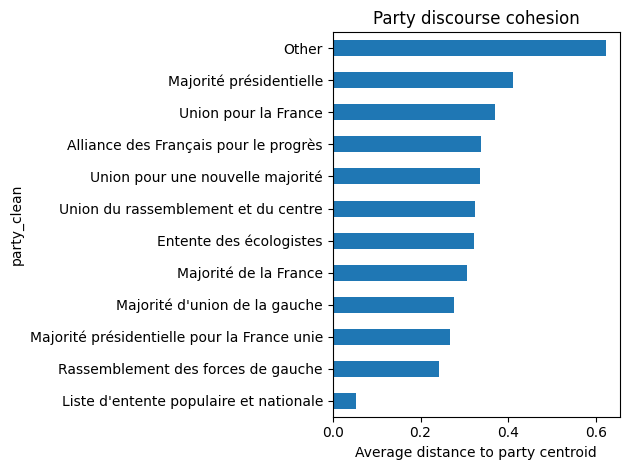

In [80]:
import matplotlib.pyplot as plt

party_dispersion.plot(kind="barh")

plt.xlabel("Average distance to party centroid")
plt.title("Party discourse cohesion")
plt.tight_layout()

plt.show()

In [81]:
df.groupby("party_clean")["party_distance"].agg(["mean","std","count"])

,mean,std,count
party_clean,,,
Alliance des Français pour le progrès,0.338107,0.170693,155
Entente des écologistes,0.321449,0.240718,421
Liste d'entente populaire et nationale,0.052163,0.122770,450
Majorité d'union de la gauche,0.276887,0.135506,140
Majorité de la France,0.306263,0.199571,172
Majorité présidentielle,0.410885,0.159476,55
Majorité présidentielle pour la France unie,0.266789,0.145402,287
Other,0.622783,0.207313,864
Rassemblement des forces de gauche,0.241629,0.139181,266


In [82]:
from scipy.spatial.distance import cosine

topics = [c for c in df.columns if c.startswith("Topic_")]

party_centroids = df.groupby("party_clean")[topics].mean()

distances = []

for _, row in df.iterrows():

    party = row["party_clean"]
    doc_vector = row[topics].values
    centroid = party_centroids.loc[party].values

    dist = cosine(doc_vector, centroid)

    distances.append(dist)

df["party_distance"] = distances

In [83]:
party_dispersion = (
    df.groupby("party_clean")["party_distance"]
    .mean()
    .sort_values()
)

party_dispersion

party_clean
Liste d'entente populaire et nationale         0.010229
Rassemblement des forces de gauche             0.054224
Majorité présidentielle pour la France unie    0.065245
Majorité de la France                          0.096330
Majorité d'union de la gauche                  0.098808
Entente des écologistes                        0.112024
Union du rassemblement et du centre            0.113315
Union pour une nouvelle majorité               0.120778
Alliance des Français pour le progrès          0.135114
Union pour la France                           0.146443
Majorité présidentielle                        0.172981
Other                                          0.445433
Name: party_distance, dtype: float64

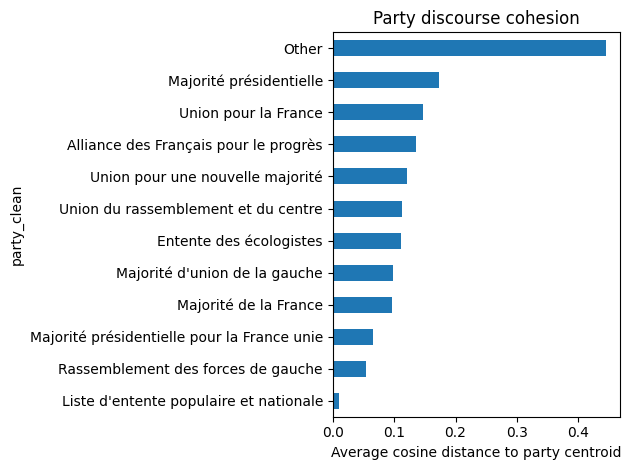

In [84]:
import matplotlib.pyplot as plt

party_dispersion.plot(kind="barh")

plt.xlabel("Average cosine distance to party centroid")
plt.title("Party discourse cohesion")
plt.tight_layout()

plt.show()

In [85]:
topics = [c for c in df.columns if c.startswith("Topic_")]

party_topic_means = df.groupby("party_clean")[topics].mean()

party_influence = party_topic_means.max(axis=1)

party_dispersion

party_clean
Liste d'entente populaire et nationale         0.010229
Rassemblement des forces de gauche             0.054224
Majorité présidentielle pour la France unie    0.065245
Majorité de la France                          0.096330
Majorité d'union de la gauche                  0.098808
Entente des écologistes                        0.112024
Union du rassemblement et du centre            0.113315
Union pour une nouvelle majorité               0.120778
Alliance des Français pour le progrès          0.135114
Union pour la France                           0.146443
Majorité présidentielle                        0.172981
Other                                          0.445433
Name: party_distance, dtype: float64

In [86]:
comparison_df = pd.DataFrame({
    "cohesion": party_dispersion,
    "influence": party_influence
})

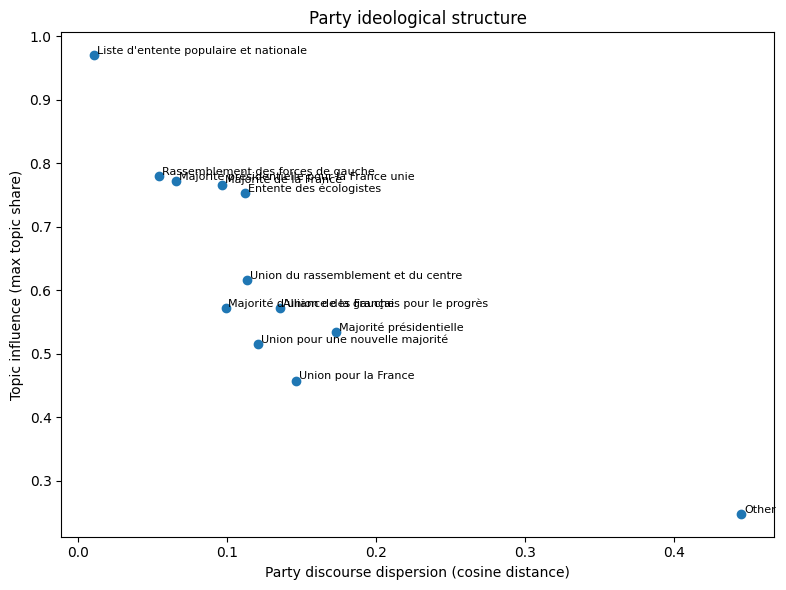

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    comparison_df["cohesion"],
    comparison_df["influence"]
)

for party, row in comparison_df.iterrows():
    plt.text(
        row["cohesion"] + 0.002,
        row["influence"] + 0.002,
        party,
        fontsize=8
    )

plt.xlabel("Party discourse dispersion (cosine distance)")
plt.ylabel("Topic influence (max topic share)")
plt.title("Party ideological structure")

plt.tight_layout()
plt.show()

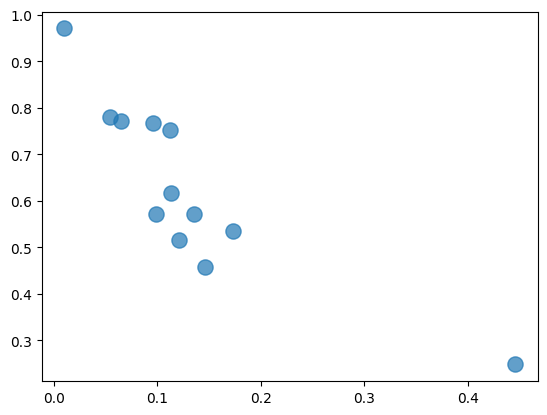

In [95]:
plt.scatter(
    comparison_df["cohesion"],
    comparison_df["influence"],
    s=120,
    alpha=0.7
)


In [96]:
df["year"].unique()


array([1981, 1988, 1993])

In [97]:
years = sorted(df["year"].unique())

In [98]:
import statsmodels.formula.api as smf
import pandas as pd

topics = [c for c in df.columns if c.startswith("Topic_")]

temporal_results = []

for year in years:
    
    df_year = df[df["year"] == year]
    
    for topic in topics:
        
        full = smf.ols(
            f"{topic} ~ C(party_clean) + C(profession_clean)",
            data=df_year
        ).fit()
        
        no_party = smf.ols(
            f"{topic} ~ C(profession_clean)",
            data=df_year
        ).fit()
        
        party_partial = full.rsquared - no_party.rsquared
        
        temporal_results.append({
            "year": year,
            "topic": topic,
            "party_R2": party_partial
        })

temporal_df = pd.DataFrame(temporal_results)

In [99]:
temporal_summary = temporal_df.groupby("year")["party_R2"].mean()

temporal_summary

year
1981    0.134002
1988    0.318783
1993    0.170519
Name: party_R2, dtype: float64

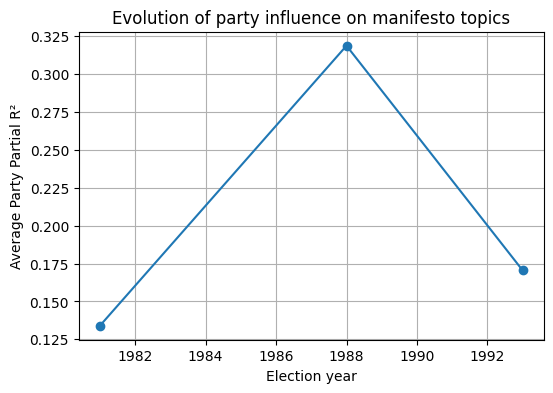

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    temporal_summary.index,
    temporal_summary.values,
    marker="o"
)

plt.xlabel("Election year")
plt.ylabel("Average Party Partial R²")
plt.title("Evolution of party influence on manifesto topics")

plt.grid(True)
plt.show()

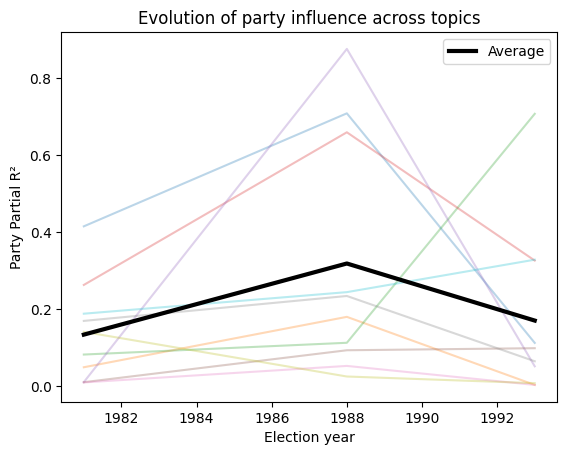

In [101]:
for topic in topics:
    
    topic_data = temporal_df[temporal_df["topic"] == topic]
    
    plt.plot(
        topic_data["year"],
        topic_data["party_R2"],
        alpha=0.3
    )

plt.plot(
    temporal_summary.index,
    temporal_summary.values,
    color="black",
    linewidth=3,
    label="Average"
)

plt.legend()
plt.xlabel("Election year")
plt.ylabel("Party Partial R²")
plt.title("Evolution of party influence across topics")

plt.show()

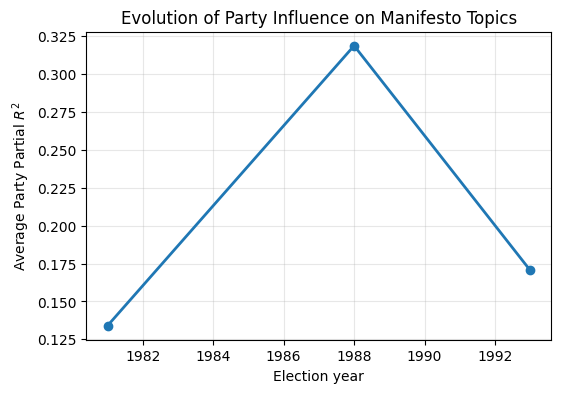

In [102]:
plt.figure(figsize=(6,4))

plt.plot(
    temporal_summary.index,
    temporal_summary.values,
    marker="o",
    linewidth=2
)

plt.ylabel("Average Party Partial $R^2$")
plt.xlabel("Election year")
plt.title("Evolution of Party Influence on Manifesto Topics")

plt.grid(alpha=0.3)